<a href="https://colab.research.google.com/github/Supieiei/Project1_Group7/blob/Phichayathida-kp/Part_1_%E0%B8%9E%E0%B8%B4%E0%B8%8A%E0%B8%8D%E0%B8%98%E0%B8%B4%E0%B8%94%E0%B8%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# พิชญธิดา ขัตติยะ 673020638-7

---
# Part 1: Social Listening Warm-up
*งานเดี่ยว — ทุกคนต้องทำและส่งของตนเอง ไม่ต้องนำเสนอ (10 คะแนน)*

ใช้ข้อมูลโพสต์สาธารณะจาก **Bluesky**  
https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

ใช้เพียง **1–3 ไฟล์** ก็พอ ไม่จำเป็นต้องโหลดทั้ง dataset

ฟิลด์ที่มี เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`, `predicted_language`

## ตอบ 4 คำถามหลัก

1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ
4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

> Part 1 เป็น warm-up ไม่ต้องทำ influencer analysis หรือ reply-network เว้นแต่สนใจทำเพิ่มเอง

In [ ]:
# ----------------- Your code here -----------------
# ใบ้: อ่าน JSON lines ทีละบรรทัดด้วย generator ไม่ต้องโหลดทั้งไฟล์
# def iter_jsonl(path):
#     with open(path, encoding='utf-8') as f:
#         for line in f:
#             yield json.loads(line)

In [33]:
!pip install langdetect -q
import pandas as pd
import json
import re
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from langdetect import DetectorFactory, detect
from tqdm.notebook import tqdm

In [12]:
def iter_jsonl(path):
    with open(path, encoding="utf-8") as f:
        for line in f:
            yield json.loads(line)

# สร้าง List เก็บพาธของทั้ง 2 ไฟล์
file_paths = ["posts_20241127_120237.jsonl", "posts_20241127_143458.jsonl"]

# 1. รวบรวมข้อมูลจากทุกไฟล์เข้า List
all_rows = []
for path in file_paths:
    for data in iter_jsonl(path):
        all_rows.append(data)

# 2. แปลงเป็น DataFrame (ตาราง)
df = pd.DataFrame(all_rows)
df

,text,created_at,author,uri,has_images,reply_to
0,Same here Tanis! Was a lovely time ❤️,2024-11-27T12:02:36.821Z,did:plc:drbw223wpmvnnkpoxjsr36du,at://did:plc:drbw223wpmvnnkpoxjsr36du/app.bsky...,False,at://did:plc:bywg42wvodfgeccofhlzgy7v/app.bsky...
1,What is this place? #bluesky,2024-11-27T12:02:36.987Z,did:plc:dkv6csztjlzhh3hqk7z3asrj,at://did:plc:dkv6csztjlzhh3hqk7z3asrj/app.bsky...,False,None
2,😮‍💨,2024-11-27T12:02:37.170Z,did:plc:h3vh4vyfnic4akr47mjtmqli,at://did:plc:h3vh4vyfnic4akr47mjtmqli/app.bsky...,False,None
3,We've picked our favourite sports books for Xm...,2024-11-27T12:02:33.573Z,did:plc:gcusr2pl22sf7nwlwf5msxsa,at://did:plc:gcusr2pl22sf7nwlwf5msxsa/app.bsky...,True,None
4,運良く入場できたらな。入り口の脇に「○○分待ち」の看板が用意してあった,2024-11-27T12:02:36.665Z,did:plc:of4fr4ranpets7xlri2u6b34,at://did:plc:of4fr4ranpets7xlri2u6b34/app.bsky...,False,at://did:plc:isvyr36mxukx6nbnvhoepcpm/app.bsky...
...,...,...,...,...,...,...
199995,Ждём рецепт фалафеля!,2024-11-27T14:51:41.837Z,did:plc:zeol424ptvfhv3tha4rimcwz,at://did:plc:zeol424ptvfhv3tha4rimcwz/app.bsky...,False,at://did:plc:gk5lbr3awjg7vm7fbd4mihp6/app.bsky...
199996,Excellent (and sorely needed) contribution to ...,2024-11-27T14:51:42.482Z,did:plc:py5tl2igp4qg3jvzpgxfbo5m,at://did:plc:py5tl2igp4qg3jvzpgxfbo5m/app.bsky...,False,at://did:plc:c2wy2wczhqsv2dkrgio3klis/app.bsky...
199997,"Could I be added, please? 🙏🏾",2024-11-27T14:51:43.553Z,did:plc:3iaomw7afvuqguy77xzunbeh,at://did:plc:3iaomw7afvuqguy77xzunbeh/app.bsky...,False,at://did:plc:2ubvjpysplbcztkkaynnbsj5/app.bsky...
199998,Prophecy ProductionsとZERO DIMENSIONAL RECORDSの...,2024-11-27T14:51:43.467Z,did:plc:zp44dyatpaxdrsgg6np7kovk,at://did:plc:zp44dyatpaxdrsgg6np7kovk/app.bsky...,False,None


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [7]:
df.columns

Index(['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to'], dtype='object')

## 1.**คนโพสต์เมื่อไร**: จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด

In [8]:
for data in iter_jsonl("posts_20241127_120237.jsonl"):
    print("เวลาที่โพสต์:", data.get("created_at"))

เอาต์พุตของการสตรีมมีการตัดเหลือเพียง 5000 บรรทัดสุดท้าย
เวลาที่โพสต์: 2024-11-27T12:23:43.136Z
เวลาที่โพสต์: 2024-11-27T12:23:41.810Z
เวลาที่โพสต์: 2018-08-22T06:33:24.000Z
เวลาที่โพสต์: 2024-11-27T12:23:43.569Z
เวลาที่โพสต์: 2024-11-27T12:23:37.176Z
เวลาที่โพสต์: 2024-11-27T12:23:42.241Z
เวลาที่โพสต์: 2024-11-27T12:23:42.623Z
เวลาที่โพสต์: 2024-11-27T12:23:43.097Z
เวลาที่โพสต์: 2024-11-27T12:23:40.910Z
เวลาที่โพสต์: 2024-11-27T12:23:44.736Z
เวลาที่โพสต์: 2024-11-27T12:23:43.583Z
เวลาที่โพสต์: 2024-11-27T12:23:43.154Z
เวลาที่โพสต์: 2024-11-27T12:23:43.476Z
เวลาที่โพสต์: 2024-11-27T12:23:41.897Z
เวลาที่โพสต์: 2024-11-27T12:23:42.682Z
เวลาที่โพสต์: 2024-11-27T12:23:43.444Z
เวลาที่โพสต์: 2024-11-27T12:23:43.445Z
เวลาที่โพสต์: 2014-06-30T19:27:38Z
เวลาที่โพสต์: 2024-11-27T12:23:42.511Z
เวลาที่โพสต์: 2014-06-30T19:25:56Z
เวลาที่โพสต์: 2024-11-27T12:23:42.863Z
เวลาที่โพสต์: 2024-11-27T12:23:38.989Z
เวลาที่โพสต์: 2024-11-27T12:23:41.459Z
เวลาที่โพสต์: 2024-11-27T12:23:43.184Z
เวลาที่โพสต์: 2

In [10]:
all_data = [
    data
    for path in file_paths
    for data in iter_jsonl(path)
    if "created_at" in data]
df = pd.DataFrame(all_data)

# แปลงตัวเลขเป็น 'X' เพื่อดูโครงสร้างของข้อความ (Format Pattern)
patterns = df["created_at"].astype(str).str.replace(r"\d", "X", regex=True)
format_counts = patterns.value_counts()

# แสดงผลการตรวจสอบ
print(f"=== ผลการตรวจเช็ค Format (รวมทั้งหมด {len(df):,} รายการ) ===")
print(f"พบ Format ทั้งหมด: {len(format_counts)} รูปแบบ\n")

print("จำนวนของแต่ละ Format:")
for fmt, count in format_counts.items():
    print(f"  - โครงสร้าง `{fmt}` : {count:,} รายการ")

# คำนวณจำนวนที่ไม่เหมือน Format หลัก
main_format = format_counts.index[0]
main_count = format_counts.iloc[0]
different_count = len(df) - main_count

=== ผลการตรวจเช็ค Format (รวมทั้งหมด 200,000 รายการ) ===
พบ Format ทั้งหมด: 15 รูปแบบ

จำนวนของแต่ละ Format:
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XX.XXXZ` : 188,455 รายการ
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XXZ` : 8,005 รายการ
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XX.XXXXXXZ` : 1,415 รายการ
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XX.XXXXXX+XX:XX` : 717 รายการ
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XX+XX:XX` : 609 รายการ
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XX-XX:XX` : 481 รายการ
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XX.XXXXXXXXZ` : 210 รายการ
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XX.XXXXXXXZ` : 33 รายการ
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XX.XXXXXX-XX:XX` : 33 รายการ
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XX.XXX+XX:XX` : 29 รายการ
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XX.XXXXXXX+XX:XX` : 5 รายการ
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XX.XXXXXXXXXZ` : 3 รายการ
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XX.XXX-XX:XX` : 2 รายการ
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XX.XXXXXXX-XX:XX` : 2 รายการ
  - โครงสร้าง `XXXX-XX-XXTXX:XX:XX.XX+XX:XX` : 1 รายการ


In [14]:
# อ่านและแปลงข้อมูลด้วยโค้ดที่ยืดหยุ่น (format='ISO8601')
# เพิ่ม errors='coerce' เพื่อเปลี่ยนข้อมูลที่เสียจริงๆ ให้กลายเป็น NaT (Not a Time)
df["created_at"] = pd.to_datetime(df["created_at"], format="ISO8601", errors="coerce")

# เช็คตัวเลขจำนวนข้อมูลและค่าผิดพลาด
valid_count = df["created_at"].notna().sum()
invalid_count = df["created_at"].isna().sum()

# กรองเอาเฉพาะข้อมูลที่ถูกต้องไปใช้วิเคราะห์ต่อ
df = df.dropna(subset=["created_at"])

print("=== 📊 1. รายงานตรวจสอบตัวเลขจำนวนข้อมูล ===")
print(f"• จำนวนโพสต์ทั้งหมด: {len(df):,} โพสต์")
print(f"• จำนวนโพสต์ที่แปลงเวลาสำเร็จ   : {valid_count:,} โพสต์")
print(f"• จำนวนโพสต์ที่ผิดพลาด/เป็นค่าว่าง : {invalid_count:,} โพสต์")

# เช็คตารางตัวเลขแจกแจงรายชั่วโมง
hourly_df = (
    df["created_at"]
    .dt.hour.value_counts()
    .sort_index()
    .reset_index(name="จำนวนโพสต์"))
hourly_df.columns = ["ชั่วโมง (น.)", "จำนวนโพสต์"]

print("\n=== 📈 2. ตารางแจกแจงจำนวนโพสต์ในแต่ละชั่วโมง ===")
print(hourly_df.to_string(index=False))

peak_hour = int(df["created_at"].dt.hour.value_counts().idxmax())
peak_count = int(df["created_at"].dt.hour.value_counts().max())

print("\n" + "=" * 45)
print("=== 🎯 3. สรุปคำตอบ 3 ข้อ ===")
print(f"1. จำนวนโพสต์ทั้งหมดที่สมบูรณ์: {valid_count:,} โพสต์")
print(f"2. ช่วงเวลาที่ครอบคลุม: ตั้งแต่ {df['created_at'].min()} ถึง {df['created_at'].max()} (UTC)")
print(f"3. ชั่วโมงที่โพสต์มากที่สุด: ช่วงเวลา {peak_hour:02d}:00 น. - {peak_hour:02d}:59 น. (จำนวน {peak_count:,} โพสต์)")

=== 📊 1. รายงานตรวจสอบตัวเลขจำนวนข้อมูล ===
• จำนวนโพสต์ทั้งหมด: 199,295 โพสต์
• จำนวนโพสต์ที่แปลงเวลาสำเร็จ   : 199,295 โพสต์
• จำนวนโพสต์ที่ผิดพลาด/เป็นค่าว่าง : 705 โพสต์

=== 📈 2. ตารางแจกแจงจำนวนโพสต์ในแต่ละชั่วโมง ===
 ชั่วโมง (น.)  จำนวนโพสต์
            0         388
            1         368
            2         326
            3         290
            4         257
            5         222
            6         291
            7         346
            8         465
            9         578
           10         582
           11         833
           12       94033
           13         865
           14       93657
           15         896
           16         713
           17         728
           18         627
           19         694
           20         675
           21         586
           22         479
           23         396

=== 🎯 3. สรุปคำตอบ 3 ข้อ ===
1. จำนวนโพสต์ทั้งหมดที่สมบูรณ์: 199,295 โพสต์
2. ช่วงเวลาที่ครอบคลุม: ตั้งแต่ 2008-04-16 18:36:2

1. **จำนวนโพสต์ทั้งหมดที่สมบูรณ์**: 199,295 โพสต์
2. **ช่วงเวลาที่ครอบคลุม**: ตั้งแต่ 2008-04-16 18:36:20+00:00 ถึง 2024-11-28 07:18:20.503000+00:00 (UTC)
3. **ชั่วโมงที่โพสต์มากที่สุด**: ช่วงเวลา 12:00 น. - 12:59 น. (จำนวน 94,033 โพสต์)

## 2.**ใช้ภาษาอะไร**: รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด

In [50]:
# ตั้งค่าให้ผลการวิเคราะห์ภาษาเสถียร
DetectorFactory.seed = 0

# เปิดใช้งาน Progress Bar เพื่อดูเปอร์เซ็นต์ความคืบหน้า
tqdm.pandas(desc="⏳ กำลังวิเคราะห์ภาษา")

# 1. สุ่มตัวอย่าง 10,000 โพสต์ (หรือปรับเป็น 5,000 ก็ได้)
sample_size = min(10000, len(df))
df_sample = df.sample(n=sample_size, random_state=42).copy()

# ฟังก์ชันตรวจจับภาษาพร้อมจัดการ Error (กรณีข้อความสั้นเกินไปหรือเป็นอิโมจิล้วน)
def detect_language(text):
    if not isinstance(text, str) or not text.strip() :
        return "unknown"
    try :
        return detect(text)
    except :
        return "unknown"

print("⏳ กำลังวิเคราะห์ภาษาจากข้อความ...")
df["language"] = df["text"].apply(detect_language)

# 5. สรุปตารางสัดส่วน (Percentage)
summary_df = df["language"].value_counts().reset_index()
summary_df.columns = ["รหัสภาษา (Language Code)", "จำนวนโพสต์"]
summary_df["สัดส่วน (%)"] = (
    summary_df["จำนวนโพสต์"] / len(df) * 100).round(2)

print("\n=== 📊 1. สัดส่วนภาษาทั้งหมดในข้อมูล ===")
print(summary_df.head(10).to_string(index=False))

⏳ กำลังวิเคราะห์ภาษาจากข้อความ...

=== 📊 1. สัดส่วนภาษาทั้งหมดในข้อมูล ===
รหัสภาษา (Language Code)  จำนวนโพสต์  สัดส่วน (%)
                      en      103344        51.67
                      ja       26080        13.04
                 unknown       11921         5.96
                      pt        8932         4.47
                      es        8173         4.09
                      fr        6932         3.47
                      de        5672         2.84
                      ko        4242         2.12
                      nl        2088         1.04
                      it        1853         0.93


/tmp/ipykernel_1747/156940869.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top10, x="Percentage (%)", y="Language", palette="viridis")


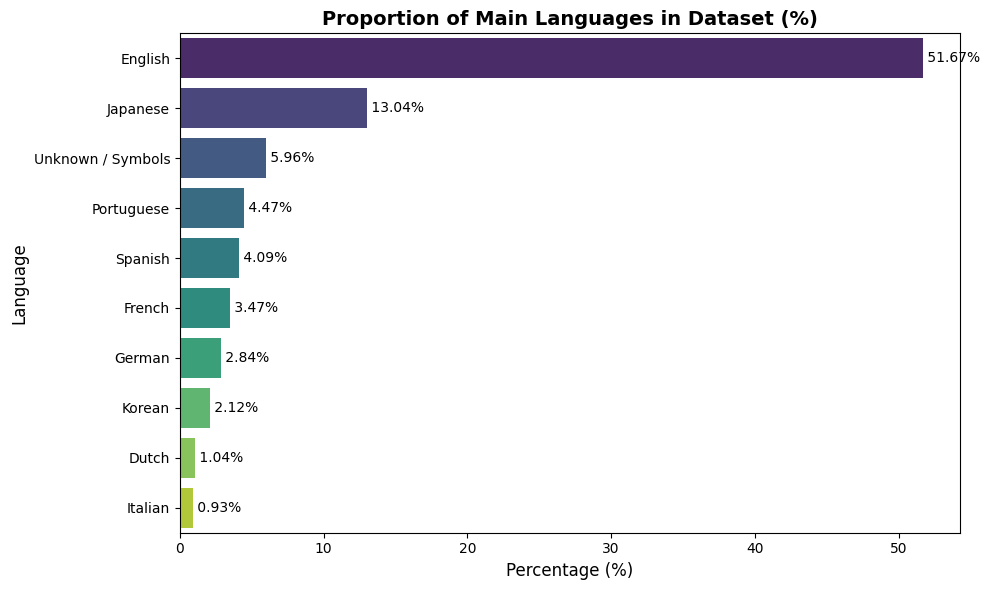

In [51]:
LANG_NAMES = {
    "en": "English",
    "ja": "Japanese",
    "pt": "Portuguese",
    "es": "Spanish",
    "fr": "French",
    "de": "German",
    "ko": "Korean",
    "nl": "Dutch",
    "it": "Italian",
    "th": "Thai",
    "zh-cn": "Chinese (Simplified)",
    "zh-tw": "Chinese (Traditional)",
    "ru": "Russian",
    "id": "Indonesian",
    "vi": "Vietnamese",
    "unknown": "Unknown / Symbols",}

df["language_name"] = df["language"].map(
    lambda x: LANG_NAMES.get(x, f"Other ({x})"))

# สรุปตาราง summary_df ใหม่โดยใช้คอลัมน์ชื่อภาษาเต็ม (จุดสำคัญ)
summary_df = df["language_name"].value_counts().reset_index()
summary_df.columns = ["Language", "Post Count"]
summary_df["Percentage (%)"] = (summary_df["Post Count"] / len(df) * 100).round(2)

plt.figure(figsize=(10, 6))
top10 = summary_df.head(10)

ax = sns.barplot(data=top10, x="Percentage (%)", y="Language", palette="viridis")
plt.title(
    "Proportion of Main Languages in Dataset (%)",
    fontsize=14,
    fontweight="bold",)
plt.xlabel("Percentage (%)", fontsize=12)
plt.ylabel("Language", fontsize=12)

# แสดงตัวเลข % ด้านขวาของทุกแท่งกราฟ
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f" {width:.2f}%",
            (width, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=10,)

plt.tight_layout()
plt.show()

In [30]:
# ดูว่าใน unknown เป็นข้อความแบบไหน
pd.set_option("display.max_colwidth", None)
df[df["language"] == "unknown"][["text"]]

,text
2,😮‍💨
6,
19,😂🥰
20,🙏🏻🙏🏻🙏🏻
28,🤣🤣🤣
...,...
199919,😂
199939,🏈👌
199946,💛💙🤍
199981,


## 3.**คนพูดถึงอะไร**: หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ

/tmp/ipykernel_1747/281815755.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=hashtag_df, x="Count", y="Hashtag", palette="viridis")


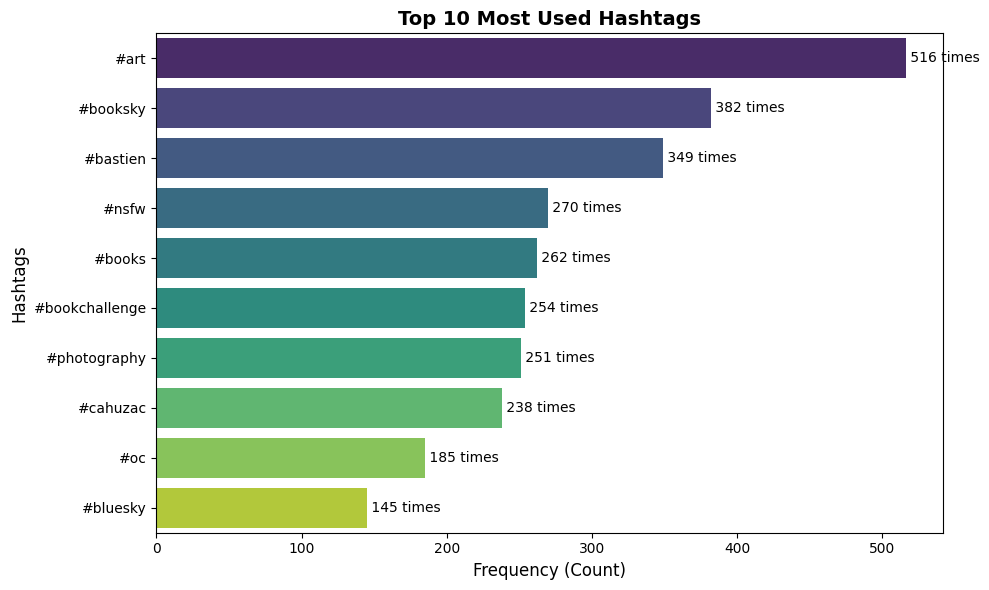

In [48]:
# อ่านข้อมูลเฉพาะคอลัมน์ text
all_texts = [
    data["text"]
    for path in file_paths
    for data in iter_jsonl(path)
    if "text" in data and isinstance(data["text"], str)]
df_text = pd.DataFrame({"text": all_texts})

# ฟังก์ชันสกัด Hashtags (รองรับภาษาไทย อังกฤษ ตัวเลข และ Underscore)
def extract_hashtags(text):
    if not isinstance(text, str):
        return []
    return re.findall(r"#[\w\u0E00-\u0E7F_]+", text, re.UNICODE)

# ดึงและนับความถี่ของ Hashtag 10 อันดับแรก (ปรับเป็นตัวพิมพ์เล็กเพื่อไม่ให้นับซ้ำ)
all_hashtags = [
    hashtag.lower()
    for text in df["text"]
    for hashtag in extract_hashtags(text)]
top_hashtags = Counter(all_hashtags).most_common(10)

# แปลงผลลัพธ์เป็น DataFrame สำหรับใช้วาดกราฟ
hashtag_df = pd.DataFrame(top_hashtags, columns=["Hashtag", "Count"])

# สร้างกราฟแท่งแนวนอน
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=hashtag_df, x="Count", y="Hashtag", palette="viridis")

plt.title("Top 10 Most Used Hashtags", fontsize=14, fontweight="bold")
plt.xlabel("Frequency (Count)", fontsize=12)
plt.ylabel("Hashtags", fontsize=12)

# แสดงตัวเลขจำนวนครั้งที่พบด้านขวาของทุกแท่งกราฟ
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f" {int(width):,} times",
            (width, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=10,)

plt.tight_layout()
plt.show()

In [41]:
data = []
for tag, count in top_hashtags:
    # ดึง 2 ตัวอย่างแรกที่ไม่ซ้ำกัน
    samples = (
        df[
            df["text"]
            .astype(str)
            .str.contains(re.escape(tag), case=False, na=False)]["text"]
        .drop_duplicates()
        .head(2)
        .tolist())

    # จัดการความสะอาดข้อความ
    ex1 = " ".join(samples[0].split()) if len(samples) > 0 else "-"
    ex2 = " ".join(samples[1].split()) if len(samples) > 1 else "-"

    data.append(
        {   "Hashtag": tag,
            "จำนวนครั้ง": f"{count:,}",
            "ตัวอย่างโพสต์ที่ 1": ex1,
            "ตัวอย่างโพสต์ที่ 2": ex2,})

# 3. แปลงเป็น DataFrame และตั้งค่าไม่ให้ตัดข้อความยาว (...)
hashtag_table = pd.DataFrame(data)
pd.set_option("display.max_colwidth", None)

# แสดงผลเป็นตารางสวยงามใน Colab
display(hashtag_table)

,Hashtag,จำนวนครั้ง,ตัวอย่างโพสต์ที่ 1,ตัวอย่างโพสต์ที่ 2
0,#art,516,100 Artworks From the Top Digital Artists in the USA & Canada – http://bit.ly/Ppfmn Truly #amazing #art!,closed | F9 🖤🤍 FABRIQUE 9 🤍🖤 an old adopt [2/20/21] owner: cenobitesquid (on DeviantArt) #adopt #adoptable #oc #blackandwhite #monster #humanoid #doll #mannequin #clipstudio #clipstudiopaint #digital #art #creature #fantasy #illustration #horror #characterdesign #myart #portfolio #artist #artists
1,#booksky,382,"Choose 20 books that have stayed with you or influenced you. One book per day for 20 days, in no particular order. No explanations, no reviews, just covers. Day 4 💙📚 #booksky #books #readingchallenge","Posting one (non-progfan) book per day, as inspired by #BookSky. Day 7: Piranesi I don't know who couldn't love this book and its protagonist. Great prose, good fantasy, and another intriguing mystery. This 2nd book by Susanna Clarke was 16 years in the making and worth every minute of waiting."
2,#bastien,349,"L'enfant, qui avait 3 ans et demi, est mort le 25 novembre 2011 après avoir été placé dans la machine à laver. #Bastien","Le procès commence. Charlène Cotte, les mais croisées devant elle, décline son identité d'une petite voix. ""J'ai pas de profession"" #Bastien"
3,#nsfw,270,Mm baby I had a dream where a thousand of your friends came over to look at at my tits. And I loved it. ❤️❤️❤️ #milf #milfsky #nsfw #nsfwsky #goonsky #realnsfw #boobsky #boobs #tits #naturaltits #natural #spicysky,"Hours later, and still managing to be horny, feel free to message #horny #nsfw"
4,#books,262,"Choose 20 books that have stayed with you or influenced you. One book per day for 20 days, in no particular order. No explanations, no reviews, just covers. Day 4 💙📚 #booksky #books #readingchallenge","Posting one (non-progfan) book per day, as inspired by #BookSky. Day 7: Piranesi I don't know who couldn't love this book and its protagonist. Great prose, good fantasy, and another intriguing mystery. This 2nd book by Susanna Clarke was 16 years in the making and worth every minute of waiting."
5,#bookchallenge,254,"Choose 20 books that have stayed with you or influenced you. One book per day for 20 days, in no particular order. No explanations, no reviews, just covers. Day 8 #BookSky 💙📚 #Books #BookChallenge","Day 11/20 Choose 20 books that have stayed with you or influenced you. One book per day for 20 days, in no particular order. No explanations, no reviews, just covers. #BookSky💙📚 #Books #BookChallenge"
6,#photography,251,Short-eared Owl at the Shawangunk Grasslands 🪶 #owls #birds #wildllifephotography #wildlife #birding #photography #nature,Snake plants 🌱 🐍 #snake #snakeplant #plants #houseplant #sansevieria #nature #photography
7,#cahuzac,238,Puisque l'ayant-droit économique reste le même : Jérôme #Cahuzac.,"""La société panaméenne est transparente pour le fisc"", explique F Rey. #Cahuzac"
8,#oc,185,#イラスト #ilustration #オリキャラ #OC ⚫️,closed | F9 🖤🤍 FABRIQUE 9 🤍🖤 an old adopt [2/20/21] owner: cenobitesquid (on DeviantArt) #adopt #adoptable #oc #blackandwhite #monster #humanoid #doll #mannequin #clipstudio #clipstudiopaint #digital #art #creature #fantasy #illustration #horror #characterdesign #myart #portfolio #artist #artists
9,#bluesky,145,What is this place? #bluesky,"""ONLY BROKE N*GGAS THINK MONEY CAN SOLVE PROBLEMS"" ATLANTIC CITY BOARDWALK #NEWJERSEY #ATLANTICCITY #BOARDWALK #DAVEEAST #SWIZZBEATS #BENNYTHEBUTCHER #ARABMUZIK #IGREELS #BLACKSKY #BLUESKY"


##4.**ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้**: สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

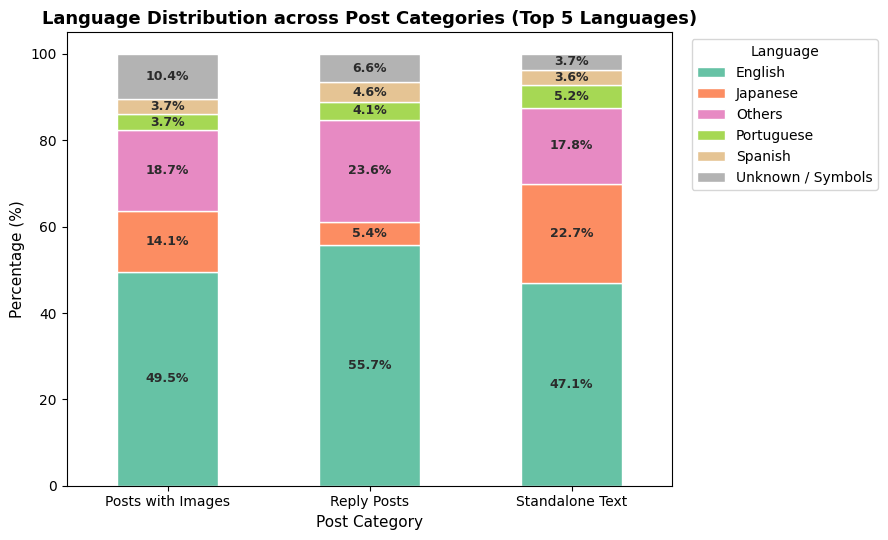

In [54]:
# 1. จัดหมวดหมู่ประเภทโพสต์ (Post Category)
df["post_category"] = df.apply(
    lambda r: (
        "Reply Posts"
        if pd.notna(r.get("reply_to"))
        else ("Posts with Images" if r.get("has_images") else "Standalone Text")),axis=1,)

# 2. เช็คชื่อคอลัมน์ภาษาที่มีใน df
lang_col = "language_name" if "language_name" in df.columns else "language"

# 3. หา 5 ภาษาหลักที่มีจำนวนสูงสุด
top_5_langs = df[lang_col].value_counts().head(5).index

# 4. จัดกลุ่ม: เก็บ 5 ภาษาหลักไว้ ส่วนที่เหลือเปลี่ยนเป็น "Others"
df["lang_top5"] = df[lang_col].apply(
    lambda x: x if x in top_5_langs else "Others")

# 5. ทำ Pivot Table คำนวณเป็นเปอร์เซ็นต์ (100% Stacked)
pivot_df = (pd.crosstab(df["post_category"], df["lang_top5"], normalize="index") * 100)

# 6. วาดกราฟ Stacked Bar Chart
ax = pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5.5),
    colormap="Set2",
    edgecolor="white",)

plt.title(
    "Language Distribution across Post Categories (Top 5 Languages)",
    fontsize=13,
    fontweight="bold",)
plt.xlabel("Post Category", fontsize=11)
plt.ylabel("Percentage (%)", fontsize=11)
plt.xticks(rotation=0)
plt.legend(title="Language", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

# เพิ่มตัวเลขสัดส่วน (%) ลงในแต่ละช่องของ Stacked Bar
for c in ax.containers:
    # กรองเฉพาะช่องที่มีค่าตั้งแต่ 3% ขึ้นไป เพื่อป้องกันตัวเลขทับกันในช่องที่เล็กมากๆ
    labels = [f"{v:.1f}%" if v >= 3 else "" for v in c.datavalues]
    ax.bar_label(
        c,
        labels=labels,
        label_type="center",
        fontsize=9,
        fontweight="bold",
        color="#2b2b2b",)
plt.tight_layout()
plt.show()

> ## วิเคราะห์จากผลลัพธ์ของกราฟ (Visualization)

### สิ่งที่กราฟนี้บอกเราได้
* **ภาษาอังกฤษคือภาษาหลัก:** ไม่ว่าจะโพสต์รูป ตอบกลับ หรือโพสต์ข้อความ ภาษาอังกฤษเป็นภาษาที่มีสัดส่วนมากที่สุดเสมอ (เกิน 47% ในทุกหมวดหมู่)
* **พฤติกรรมการใช้ภาษาตามประเภทโพสต์:**
  * เวลาตอบกลับบทสนทนา (`Reply Posts`) คนจะใช้ภาษาอังกฤษสูงที่สุด (55.7%)[cite: 8]
  * เวลาโพสต์ข้อความทั่วไป (`Standalone Text`) จะเห็นภาษาญี่ปุ่น (`Japanese`) เพิ่มขึ้นมาอย่างเห็นได้ชัด (22.7%)
* **โพสต์ที่มีรูปภาพมักใช้สัญลักษณ์:** โพสต์ที่แนบรูปภาพ (`Posts with Images`) มีสัดส่วนของข้อความที่ไม่สามารถระบุภาษาได้ หรือมีแต่สัญลักษณ์/อีโมจิ (`Unknown / Symbols`) สูงที่สุดถึง 10.4%

---

### ข้อจำกัดของกราฟนี้
1. **ไม่เห็นจำนวนโพสต์จริง:** กราฟแสดงเป็นสัดส่วนเปอร์เซ็นต์ (100%) ทำให้เราไม่รู้ว่าจริงๆ แล้วโพสต์ประเภทไหนมีจำนวนเยอะกว่ากัน
2. **เสียรายละเอียดภาษาอื่นๆ:** ภาษาที่มีคนใช้น้อยถูกเอามารวมไว้ในกลุ่ม `Others` ทำให้มองไม่เห็นความหลากหลายของภาษาที่เหลือ
3. **ไม่บอกเวลาและเนื้อหา:** กราฟนี้ไม่ได้บอกว่าโพสต์กันช่วงกี่โมง และไม่ได้บอกบริบทว่าเขากำลังคุยเรื่องอะไรกันอยู่

> ## วิเคราะห์จากภาพรวมข้อมูลทั้งหมด (Full Dataset)

### สิ่งที่ชุดข้อมูลนี้บอกเราได้
* **รูปแบบการใช้งานของผู้ใช้:** สามารถแบ่งประเภทการใช้งานได้อย่างชัดเจน เช่น โพสต์ข้อความใหม่ การตอบกลับเพื่อน (`reply_to`) หรือการแปะรูปภาพ (`has_images`)
* **ช่วงเวลาที่มีการใช้งานหนาแน่น:** บอกได้ว่าผู้ใช้โพสต์กันถี่แค่ไหนในแต่ละช่วงชั่วโมง ผ่านคอลัมน์เวลา `created_at`
* **เรื่องที่คนสนใจและภาษาที่ใช้:** สามารถสกัดดูแฮชแท็กฮิต (`#Hashtag`) และตรวจจับภาษาหลักของข้อความได้

---

### ข้อจำกัดของชุดข้อมูลทั้งหมด
1. **ไม่รู้ข้อมูลส่วนตัวผู้ใช้:** รหัสผู้ใช้ (`author`) เป็นรหัสนามสมมุติ (`did:plc:...`) ไม่สามารถระบุเพศ อายุ หรือประเทศที่อยู่ได้
2. **ไม่มีข้อมูลวัดความนิยม (Engagement):** ไม่มีข้อมูลยอดกดไลก์ (Likes) ยอดรีโพสต์ (Reposts) หรือจำนวนผู้ติดตาม จึงวัดไม่ได้ว่าโพสต์ไหนมีอิทธิพลมากกว่ากัน
3. **เป็นข้อมูลช่วงเวลาสั้นๆ:** ข้อมูลถูกเก็บมาเฉพาะช่วงเวลาหนึ่งเท่านั้น ไม่สามารถใช้สรุปพฤติกรรมระยะยาวหรือเทรนด์รายสัปดาห์ได้
4. **ไม่เห็นรูปภาพและข้อความต้นทาง:** ไม่สามารถเปิดดูไฟล์รูปภาพจริงได้ และไม่เห็นข้อความต้นฉบับที่ถูกตอบกลับ